In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [35]:
df = pd.read_csv('./datasets/TSLA.csv')
close_prices = df['Close'].values.reshape(-1, 1)
close_prices

array([[   4.778   ],
       [   4.766   ],
       [   4.392   ],
       ...,
       [ 993.97998 ],
       [ 999.109985],
       [1013.919983]], shape=(2956, 1))

In [36]:
# MinMaxScaler: 값을 [0, 1] 범위로 정규화
# RNN/LSTM은 입력 스케일에 민감하므로 정규화 필수
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close_prices)

# 시계열 데이터는 시간 순서를 유지해야 하므로 shuffle 없이 앞에서 자름
split     = int(len(scaled) * 0.8)
train_raw = scaled[:split]
test_raw  = scaled[split:]

# 슬라이딩 윈도우로 (X, y) 시퀀스 생성
# X[i]: scaled[i : i+60]  shape: (60, 1) — 과거 60일 종가
# y[i]: scaled[i+60]      shape: (1,)    — 다음 날 종가
# many-to-one: 60개 time step 입력 → 다음 1개 값 예측
seq_len = 60

def make_sequences(data):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_sequences(train_raw)
X_test,  y_test  = make_sequences(test_raw)

In [37]:
class CustomDataset(Dataset):

    # RNN input은 (batch, sequence_len, input_size) -> channel 필요 X
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)  # shape: (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

train_dataset = CustomDataset(X_train, y_train)
test_dataset  = CustomDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

In [38]:
print(len(train_dataset))
print(len(test_dataset))

2304
532


**nn.RNN(input_size, hidden_size, num_layers, batch_first, nonlinearity, dropout)**
* **input_size**: 각 time step(rows)의 feature 크기 (MNIST: 28, 이미지 width pixel 수)
* **hidden_size**: 일반적으로 128 시작, 성능 부족 시 *2, overfitting or 학습이 느린 경우 /2
* **num_layers**: 일반적으로 1~2, 깊게 쌓을수록 복잡한 시퀀스 패턴 학습 가능
* **batch_first**: True 고정 (입력 shape을 (batch, sequence, feature) 순서로 받기 위함)
* **nonlinearity**: 일반적으로 `tanh`(default), exploding gradient 우려 시 'relu' 지양
* **dropout**: num_layers > 1일 때만 적용, 일반적으로 0.2~0.5

**nn.Linear(in_features, out_features)**
* **in_features**: 첫 번째 Linear는 hidden_size와 동일, 이후는 이전 layer의 out_features와 동일
* **out_features**: hidden_size / 2로 시작해 점진적으로 1/2씩 감소, 마지막 Linear는 class 수

In [39]:
class RNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=128,        # acc가 낮다면 x2, overfitting이거나 학습이 느리면 /2
            num_layers=2,
            batch_first=True,      # 입력 shape: (batch, seq, feature) 순서
            nonlinearity='tanh',
            dropout=0.1            # num_layers > 1일 때 레이어 사이에 dropout 적용
        )

        self.fc = nn.Sequential(

            # in: hidden_size로 시작
            # out: in / 2 로 시작
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            # in: 이전 layer의 out
            # out: 회귀(regression)이므로 1
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, h_n = self.rnn(x)
        # out: (batch, sequence_len, hidden_size) — 모든 time step hidden state
        # h_n: (num_layers, batch, hidden_size) — 마지막 time step hidden state
        # nn.LSTM과 달리 기본 RNN은 cell state(c_n) 없음 -> 장기 의존성 문제

        # many-to-one: 마지막 time step의 출력만 예측에 사용
        out = self.fc(out[:, -1, :])  # (batch, hidden_size) → (batch, 1)
        return out

model = RNN()

In [40]:
# MSELoss: 회귀 문제의 표준 손실 함수 (분류의 CrossEntropyLoss 대신 사용)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [41]:
train_losses, test_losses = [], []

In [42]:
epochs = 30

for epoch in range(epochs):

    # ── Train ──
    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # BPTT: 시간 펼침 역전파
        loss.backward()
        
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ── Test ──
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs   = model(X_batch)
            loss      = criterion(outputs, y_batch)
            test_loss += loss.item()

    test_loss = test_loss / len(test_loader)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.6f} | "
          f"Test Loss: {test_loss:.6f}")

Epoch [1/30] Train Loss: 0.000683 | Test Loss: 0.246020
Epoch [2/30] Train Loss: 0.000256 | Test Loss: 0.257498
Epoch [3/30] Train Loss: 0.000079 | Test Loss: 0.276795
Epoch [4/30] Train Loss: 0.000067 | Test Loss: 0.271867
Epoch [5/30] Train Loss: 0.000057 | Test Loss: 0.279211
Epoch [6/30] Train Loss: 0.000051 | Test Loss: 0.267798
Epoch [7/30] Train Loss: 0.000043 | Test Loss: 0.272019
Epoch [8/30] Train Loss: 0.000044 | Test Loss: 0.269148
Epoch [9/30] Train Loss: 0.000036 | Test Loss: 0.253794
Epoch [10/30] Train Loss: 0.000031 | Test Loss: 0.245051
Epoch [11/30] Train Loss: 0.000030 | Test Loss: 0.242228
Epoch [12/30] Train Loss: 0.000026 | Test Loss: 0.236099
Epoch [13/30] Train Loss: 0.000022 | Test Loss: 0.230843
Epoch [14/30] Train Loss: 0.000022 | Test Loss: 0.229317
Epoch [15/30] Train Loss: 0.000017 | Test Loss: 0.226344
Epoch [16/30] Train Loss: 0.000015 | Test Loss: 0.225120
Epoch [17/30] Train Loss: 0.000016 | Test Loss: 0.233349
Epoch [18/30] Train Loss: 0.000012 | Tes

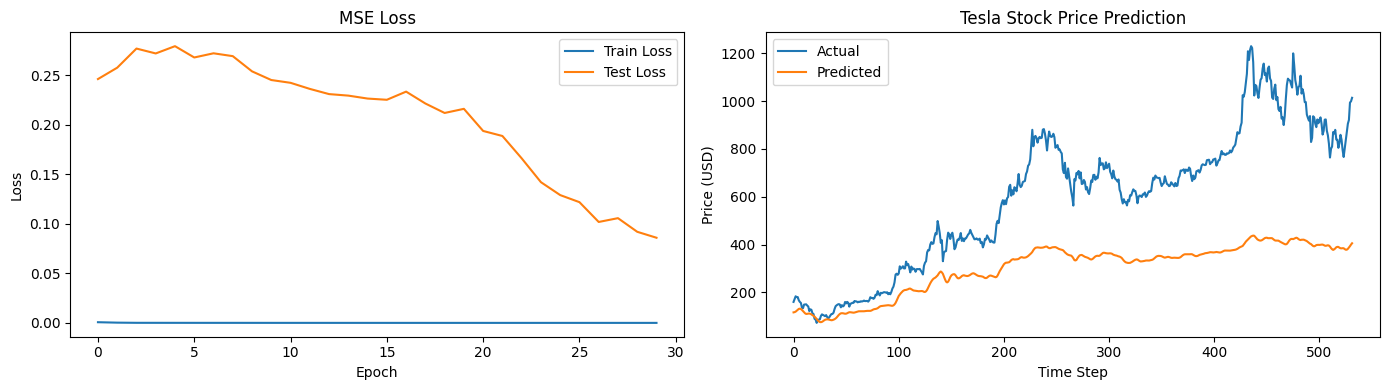

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Loss graph ──
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses,  label='Test Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ── pred vs true ──
model.eval()
predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        predictions.append(model(X_batch).numpy())

predictions = np.concatenate(predictions, axis=0)

# inverse_transform: 정규화된 예측값을 원래 주가 스케일로 복원
pred_prices   = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test)

axes[1].plot(actual_prices, label='Actual')
axes[1].plot(pred_prices,   label='Predicted')
axes[1].set_title('Tesla Stock Price Prediction')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()